# DNA Sequence Analysis with Biopython

A small, fully reproducible walkthrough: read a FASTA file, compute GC content,
find open reading frames (ORFs), translate them and look at codon usage.

**Data:** To keep this notebook runnable without internet access, the sequence is
*synthetic* (a random genome with a few planted genes, fixed random seed).
The last section shows how to swap in a real sequence from NCBI.

In [1]:
from pathlib import Path
import random
from collections import Counter

import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.SeqUtils import gc_fraction

random.seed(42)

## 1. Create a synthetic genome and save it as FASTA
Random background sequence plus 5 planted "genes" (ATG ... stop codon) on the forward strand.

In [2]:
def random_dna(n):
    return "".join(random.choice("ACGT") for _ in range(n))

STOPS = ["TAA", "TAG", "TGA"]
sense_codons = [a + b + c for a in "ACGT" for b in "ACGT" for c in "ACGT" if a + b + c not in STOPS]

def random_gene(n_codons):
    return "ATG" + "".join(random.choice(sense_codons) for _ in range(n_codons)) + random.choice(STOPS)

genome = random_dna(300)
for n_codons in (120, 200, 90, 150, 250):
    genome += random_gene(n_codons) + random_dna(random.randint(100, 300))

record = SeqRecord(Seq(genome), id="synthetic_genome", description="random genome with 5 planted genes")
Path("data").mkdir(exist_ok=True)
SeqIO.write(record, "data/synthetic_genome.fasta", "fasta")
print(f"Genome length: {len(genome)} bp")

Genome length: 3799 bp


## 2. Read the FASTA file back in

In [3]:
record = SeqIO.read("data/synthetic_genome.fasta", "fasta")
print(record.id, "-", len(record.seq), "bp")
print(record.seq[:60], "...")

synthetic_genome - 3799 bp
AAGCCCAATAAACCACTCTGACTGGCCGAATAGGGATATAGGCAACGACATGTGCGGCGA ...


## 3. GC content
Overall and in a sliding window. Local GC shifts often hint at genes, islands or horizontally transferred regions.

Overall GC content: 50.4 %


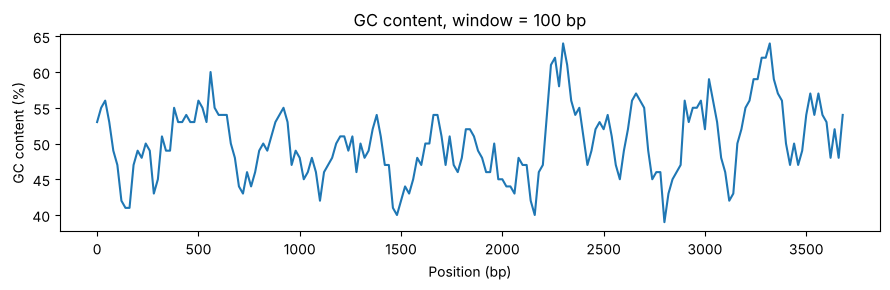

In [4]:
print(f"Overall GC content: {gc_fraction(record.seq) * 100:.1f} %")

window, step = 100, 20
positions = list(range(0, len(record.seq) - window, step))
gc_profile = [gc_fraction(record.seq[i:i + window]) * 100 for i in positions]

plt.figure(figsize=(9, 3))
plt.plot(positions, gc_profile)
plt.xlabel("Position (bp)")
plt.ylabel("GC content (%)")
plt.title(f"GC content, window = {window} bp")
plt.tight_layout()
plt.savefig("gc_profile.png", dpi=150)
plt.show()

## 4. Find ORFs
Scan all six reading frames (3 forward, 3 reverse complement) for stretches that start with ATG
and end at a stop codon. Keep only ORFs of at least 100 codons to avoid random short hits.

In [5]:
def find_orfs(seq, min_codons=100):
    orfs = []
    for strand, s in (("+", seq), ("-", seq.reverse_complement())):
        for frame in range(3):
            protein = s[frame:len(s) - ((len(s) - frame) % 3)].translate()
            aa_pos = 0
            for chunk in str(protein).split("*"):
                start = chunk.find("M")
                if start != -1 and len(chunk) - start >= min_codons:
                    nt_start = frame + (aa_pos + start) * 3
                    nt_end = nt_start + (len(chunk) - start) * 3 + 3  # include stop codon
                    orfs.append({
                        "strand": strand,
                        "frame": frame,
                        "start": nt_start,
                        "end": nt_end,
                        "length_codons": len(chunk) - start,
                        "protein": chunk[start:],
                    })
                aa_pos += len(chunk) + 1
    return orfs

orfs = sorted(find_orfs(record.seq), key=lambda o: o["length_codons"], reverse=True)
for o in orfs:
    print(o["strand"], o["frame"], o["start"], o["end"], o["length_codons"], "codons")

+ 1 2770 3526 251 codons
+ 2 896 1502 201 codons
+ 1 2191 2647 151 codons
+ 0 300 666 121 codons


## 5. Compare with the planted genes
The synthetic genome contains 5 forward-strand genes with 120, 200, 90, 150 and 250 sense codons.
Including the start codon, their ORFs are 1 codon longer (121, 201, 91, 151, 251).
The 91-codon gene is below our cut-off, so we expect exactly 4 forward hits.

In [6]:
forward = sorted([o for o in orfs if o["strand"] == "+"], key=lambda o: o["start"])
print("Forward-strand ORFs (>= 100 codons):", [o["length_codons"] for o in forward])

Forward-strand ORFs (>= 100 codons): [121, 201, 151, 251]


## 6. Translate the longest ORF

In [7]:
longest = orfs[0]
print(f"Longest ORF: {longest['length_codons']} codons, strand {longest['strand']}, "
      f"{longest['start']}-{longest['end']}")
print(longest["protein"][:80], "...")

Longest ORF: 251 codons, strand +, 2770-3526
MSVGPSSRKQFSLVSRYVLLAKLTNQISSDFVADRTYQIHTNIRGSALTTSLLAENGEAIVSQRKAPIARSGGTDPTDEE ...


## 7. Codon usage of the ORFs found

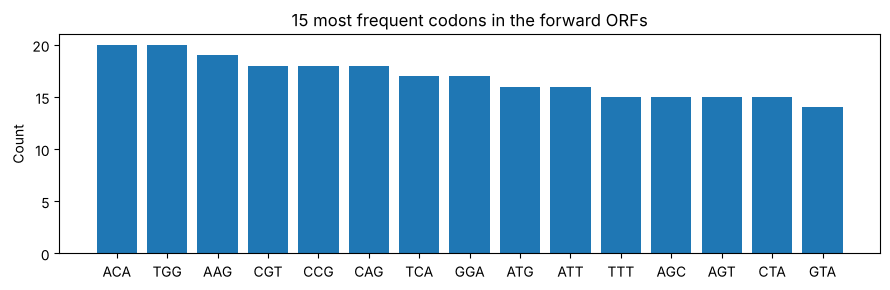

In [8]:
def orf_nucleotides(orf):
    s = record.seq if orf["strand"] == "+" else record.seq.reverse_complement()
    return str(s[orf["start"]:orf["end"]])

codons = Counter()
for o in forward:
    nt = orf_nucleotides(o)
    codons.update(nt[i:i + 3] for i in range(0, len(nt) - 3, 3))

top = codons.most_common(15)
plt.figure(figsize=(9, 3))
plt.bar([c for c, _ in top], [n for _, n in top])
plt.ylabel("Count")
plt.title("15 most frequent codons in the forward ORFs")
plt.tight_layout()
plt.savefig("codon_usage.png", dpi=150)
plt.show()

## 8. Next step: use a real sequence from NCBI
Not run here (needs internet and your e-mail address for NCBI's usage policy). Uncomment and try it:

```python
# from Bio import Entrez
# Entrez.email = "your.name@example.com"
# handle = Entrez.efetch(db="nucleotide", id="NC_001422", rtype="fasta", retmode="text")  # phage phiX174
# open("data/phix174.fasta", "w").write(handle.read())
```
Then point `SeqIO.read(...)` in section 2 to the new file and rerun everything.